# Day 8 – Strategy Dashboard & Performance Report (EURUSD)

## Objective
Create a consolidated dashboard that summarizes strategy performance, risk, and comparison results in a clear and structured format.

## Goal
Present results in a way that supports decision-making.

In [15]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [16]:
#Create Output Folders
os.makedirs("outputs/charts", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [17]:
#Load Dataset from Previous Day (Day 7)
file_path = r"C:\Users\THIS PC\quant-finance-portfolio\day-07-risk-optimization\outputs\tables\day07_data.csv"
df = pd.read_csv(file_path, index_col=0)

df.index = pd.to_datetime(df.index)


In [18]:
#Create Summary Metrics
summary = pd.DataFrame({
    "Metric": [
        "Total Return",
        "Annual Return",
        "Volatility",
        "Sharpe Ratio",
        "Max Drawdown"
    ],
    "Value": [
        df["equity"].iloc[-1] - 1,
        df["strategy_return"].mean() * 252,
        df["strategy_return"].std() * np.sqrt(252),
        (df["strategy_return"].mean()*252) / (df["strategy_return"].std()*np.sqrt(252)),
        df["drawdown"].min()
    ]
})

summary

,Metric,Value
0,Total Return,0.235159
1,Annual Return,0.016537
2,Volatility,0.108196
3,Sharpe Ratio,0.152838
4,Max Drawdown,-0.358673


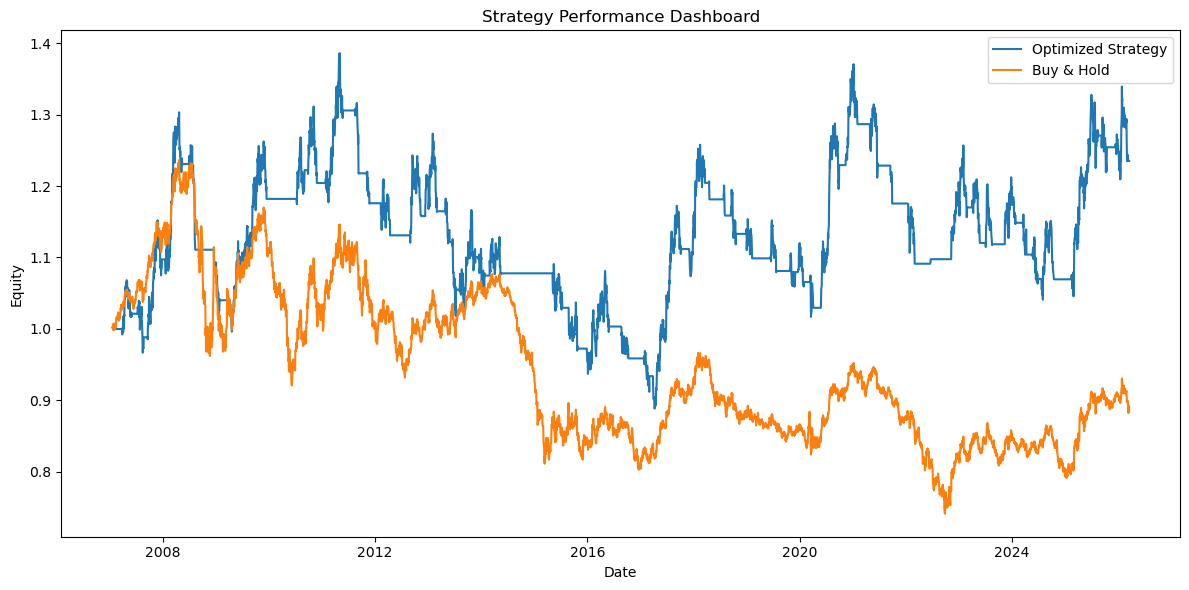

In [19]:
#Equity Curve Dashboard
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["equity"], label="Optimized Strategy")
plt.plot(df.index, df["buy_hold"], label="Buy & Hold")

plt.title("Strategy Performance Dashboard")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()

plt.tight_layout()
plt.savefig("outputs/charts/day08_equity_dashboard.png")
plt.show()

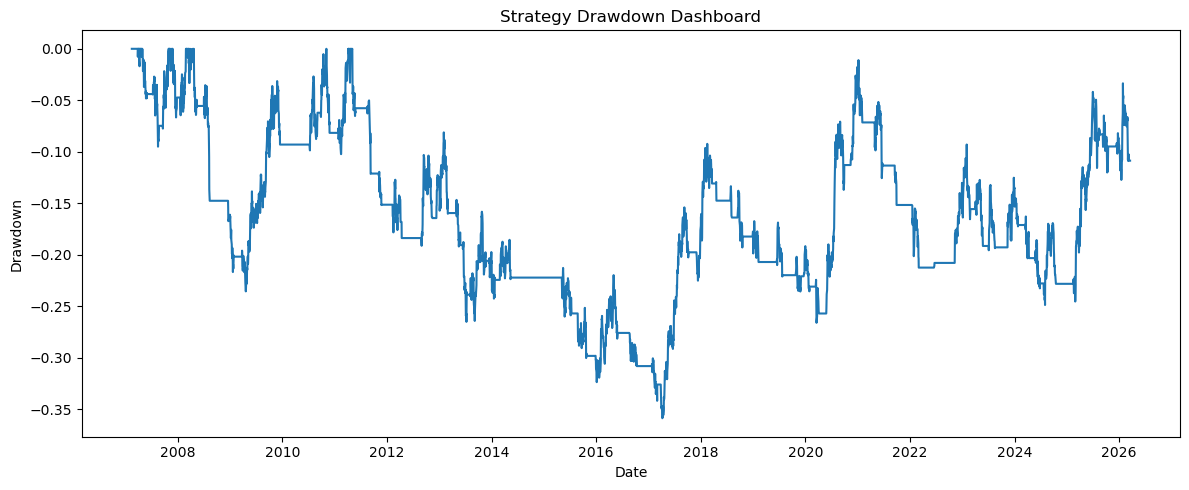

In [20]:
#Create Drawdown Chart
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["drawdown"])

plt.title("Strategy Drawdown Dashboard")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.tight_layout()
plt.savefig("outputs/charts/day08_drawdown_dashboard.png")
plt.show()

In [21]:
regime_counts = df["vol_regime"].value_counts()
print(regime_counts)


vol_regime
Low Volatility     2510
High Volatility    2490
Name: count, dtype: int64


In [22]:
#Optional summary:

regime_dashboard = df.groupby("vol_regime")["strategy_return"].agg(
    Annual_Return=lambda x: x.mean() * 252,
    Annual_Volatility=lambda x: x.std() * np.sqrt(252),
    Observations="count"
)

regime_dashboard

,Annual_Return,Annual_Volatility,Observations
vol_regime,,,
High Volatility,0.001946,0.106720,2490
Low Volatility,0.031127,0.109667,2490


In [23]:
#Save
regime_dashboard.to_csv("outputs/tables/day08_regime_dashboard.csv")

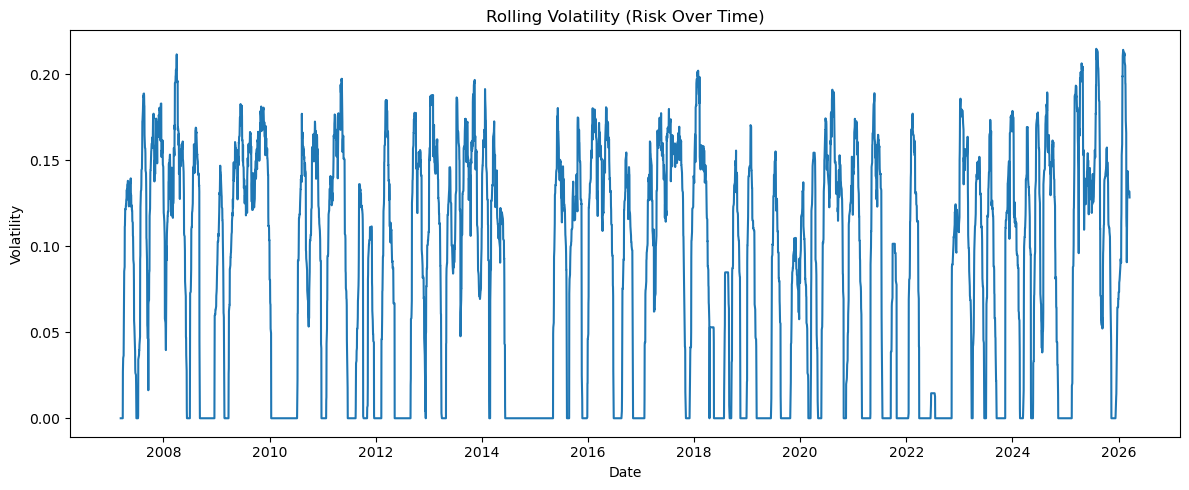

In [24]:
#Rollling Risk Advantages
df["rolling_vol"] = df["strategy_return"].rolling(20).std() * np.sqrt(252)

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["rolling_vol"])

plt.title("Rolling Volatility (Risk Over Time)")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.tight_layout()
plt.savefig("outputs/charts/day08_rolling_vol.png")
plt.show()

In [25]:
#Trade Activity
df["trade"] = df["position"].diff().abs()

total_trades = df["trade"].sum()

print("Total Trades:", total_trades)

Total Trades: 108.0


In [26]:
#Combing Everything into Report Table
report = summary.copy()
report.loc[len(report)] = ["Total Trades", total_trades]

report

,Metric,Value
0,Total Return,0.235159
1,Annual Return,0.016537
2,Volatility,0.108196
3,Sharpe Ratio,0.152838
4,Max Drawdown,-0.358673
5,Total Trades,108.000000


In [27]:
#Save Report
report.to_csv("outputs/tables/day08_report.csv", index=False)

## Analyst Interpretation

This dashboard provides a comprehensive view of the strategy’s performance, combining return, risk, and trading activity into a single framework.

The equity curve shows how the strategy grows over time compared to a passive approach, highlighting periods of strong performance and stagnation.

The drawdown chart reveals the extent of losses during unfavorable periods, offering insight into the risk experienced by a trader using this strategy.

Rolling volatility illustrates how risk changes over time, indicating periods where the market becomes more unstable.

The total number of trades reflects the level of activity and helps assess whether the strategy is overly aggressive or efficiently selective.

Overall, the dashboard highlights the balance between return, risk, and trading behavior. It reinforces that a successful strategy is not defined by returns alone, but by its consistency, stability, and ability to manage risk effectively.

## Regime Interpretation

The dashboard also separates periods of high and low volatility to provide a more structured view of market conditions. This helps avoid making conclusions purely from visual inspection.

By distinguishing market environments more formally, the analysis becomes more useful for strategy evaluation. It allows us to ask not only whether a strategy performs well, but also under what conditions it performs well.